# Fraud Detection Model Training and Evaluation


In [5]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Matplotlib backend: graphs will popup while also being saved.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


In [6]:
# ============================================================
# 1. Load the Fraud.csv dataset
# ============================================================
data = pd.read_csv("Fraud.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nMissing values:")
print(data.isnull().sum())


First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Dataset shape:
(29999, 11)

Missing values:
step              0
type              0
amount

## 2. Basic cleaning


In [7]:
# ============================================================
# 2. Basic cleaning
# ============================================================
# Fill missing numeric values with the median.
numeric_columns = data.select_dtypes(include=np.number).columns

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

# Remove rows where the target is missing, if any.
data = data.dropna(subset=["isFraud"])


## 3. Data visualization


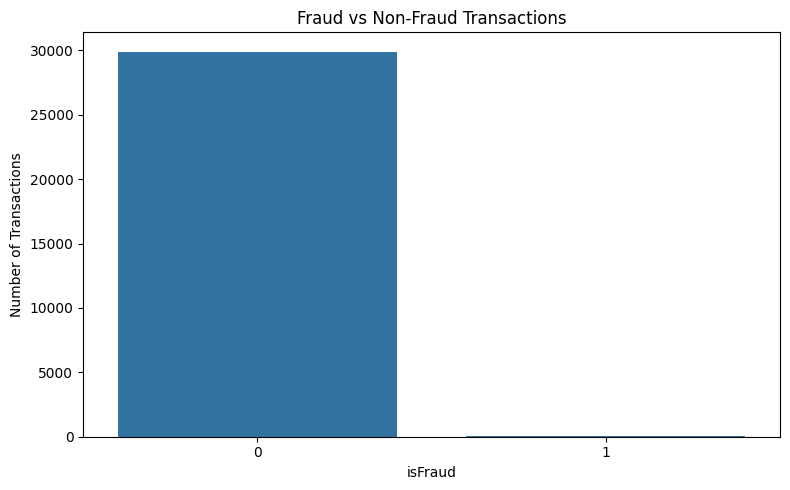

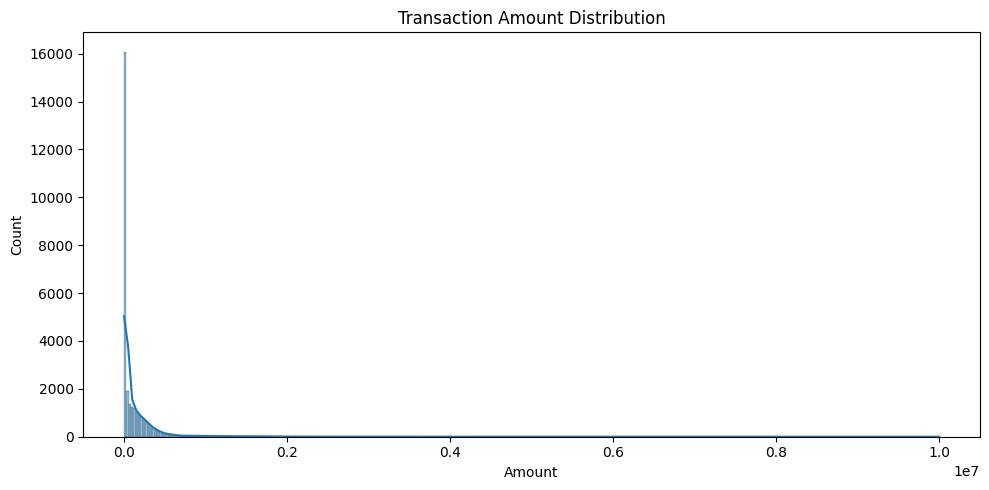

In [8]:
# ============================================================
# 3. Data visualization
# ============================================================
plt.figure(figsize=(8, 5))
sns.countplot(x="isFraud", data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("fraud_vs_nonfraud.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
sns.histplot(data["amount"], kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("transaction_amount_distribution.png", dpi=150)
plt.show()
plt.close()


## 4. Feature engineering


In [9]:
# ============================================================
# 4. Feature engineering
# ============================================================
# Balance changes
data["origin_balance_change"] = (
    data["oldbalanceOrg"] - data["newbalanceOrig"]
)

data["destination_balance_change"] = (
    data["newbalanceDest"] - data["oldbalanceDest"]
)

# Useful transaction flags
amount_median = data["amount"].median()

data["large_transaction"] = (
    data["amount"] > amount_median
).astype(int)

data["origin_balance_empty"] = (
    data["newbalanceOrig"] == 0
).astype(int)

data["destination_balance_empty"] = (
    data["newbalanceDest"] == 0
).astype(int)


## 5. Prepare data for machine learning


In [10]:
# ============================================================
# 5. Prepare data for machine learning
# ============================================================
# nameOrig and nameDest are identifiers, so they are removed.
data = data.drop(columns=["nameOrig", "nameDest"])

# Convert transaction type (PAYMENT, TRANSFER, CASH_OUT, etc.)
# into numeric columns.
data = pd.get_dummies(
    data,
    columns=["type"],
    drop_first=True
)

# Separate input features (X) and target (y).
X = data.drop(columns=["isFraud"])
y = data["isFraud"]


## 6. Train/test split


In [11]:
# ============================================================
# 6. Train/test split
# ============================================================
# The PaySim/Fraud dataset is very large. Use a stratified sample
# so the complete project can finish on a normal laptop.
MAX_ROWS = 500000

if len(X) > MAX_ROWS:
    X_sample, _, y_sample, _ = train_test_split(
        X,
        y,
        train_size=MAX_ROWS,
        random_state=42,
        stratify=y
    )
else:
    X_sample, y_sample = X, y

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.20,
    random_state=42,
    stratify=y_sample
)

print(f"Training/testing rows used: {len(X_sample):,}")


Training/testing rows used: 29,999


## 7. Scale the features


In [ ]:
# ============================================================
# 7. Scale the features
# ============================================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 8. Random Forest model


In [ ]:
# ============================================================
# 8. Random Forest model
# ============================================================
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)


print("\n========================================")
print("RANDOM FOREST RESULTS")
print("========================================")

print(
    "Random Forest Model Accuracy:",
    model_rf.score(X_test, y_test)
)



RANDOM FOREST RESULTS
Random Forest Model Accuracy: 0.9985


## 9. GridSearchCV for Random Forest


In [ ]:
# ============================================================
# 9. GridSearchCV for Random Forest
# ============================================================
classifier_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    param_grid={
        "n_estimators": [50, 100]
    },
    cv=5,
    return_train_score=True,
    scoring="accuracy",
    n_jobs=-1
)

classifier_rf.fit(X_train, y_train)

results = pd.DataFrame(classifier_rf.cv_results_)

print("\nRandom Forest Grid Search Results:")
print(
    results[
        [
            "param_n_estimators",
            "mean_test_score",
            "std_test_score"
        ]
    ]
)

print("\nBest Random Forest Parameters:")
print(classifier_rf.best_params_)



Random Forest Grid Search Results:
   param_n_estimators  mean_test_score  std_test_score
0                  50         0.998708        0.000333
1                 100         0.998625        0.000449

Best Random Forest Parameters:
{'n_estimators': 50}


## 10. KNN model


In [ ]:
# ============================================================
# 10. KNN model
# ============================================================
# KNN becomes very slow on hundreds of thousands/millions of rows.
# Use a smaller stratified subset for KNN.
KNN_MAX_ROWS = 100000

if len(X_train) > KNN_MAX_ROWS:
    X_knn_train, _, y_knn_train, _ = train_test_split(
        X_train,
        y_train,
        train_size=KNN_MAX_ROWS,
        random_state=42,
        stratify=y_train
    )
else:
    X_knn_train, y_knn_train = X_train, y_train

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_knn_train, y_knn_train)

y_pred_knn = model_knn.predict(X_test)

print("\n========================================")
print("KNN RESULTS")
print("========================================")

print(
    "KNN Model Accuracy:",
    model_knn.score(X_test, y_test)
)



KNN RESULTS
KNN Model Accuracy: 0.9981666666666666


## 11. KNN GridSearchCV


In [ ]:
# ============================================================
# 11. KNN GridSearchCV
# ============================================================
classifier_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [3, 5, 7]
    },
    cv=5,
    return_train_score=True,
    scoring="accuracy",
    n_jobs=-1
)

classifier_knn.fit(X_knn_train, y_knn_train)

results_knn = pd.DataFrame(
    classifier_knn.cv_results_
)

print("\nKNN Grid Search Results:")
print(
    results_knn[
        [
            "param_n_neighbors",
            "mean_test_score",
            "std_test_score"
        ]
    ]
)

print("\nBest KNN Parameters:")
print(classifier_knn.best_params_)



KNN Grid Search Results:
   param_n_neighbors  mean_test_score  std_test_score
0                  3         0.997375        0.000283
1                  5         0.997625        0.000213
2                  7         0.997625        0.000212

Best KNN Parameters:
{'n_neighbors': 7}


## 12. Model Performance Comparison



MODEL PERFORMANCE COMPARISON
        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.998500      1.000 0.470588      0.64
          KNN  0.998167      0.875 0.411765      0.56


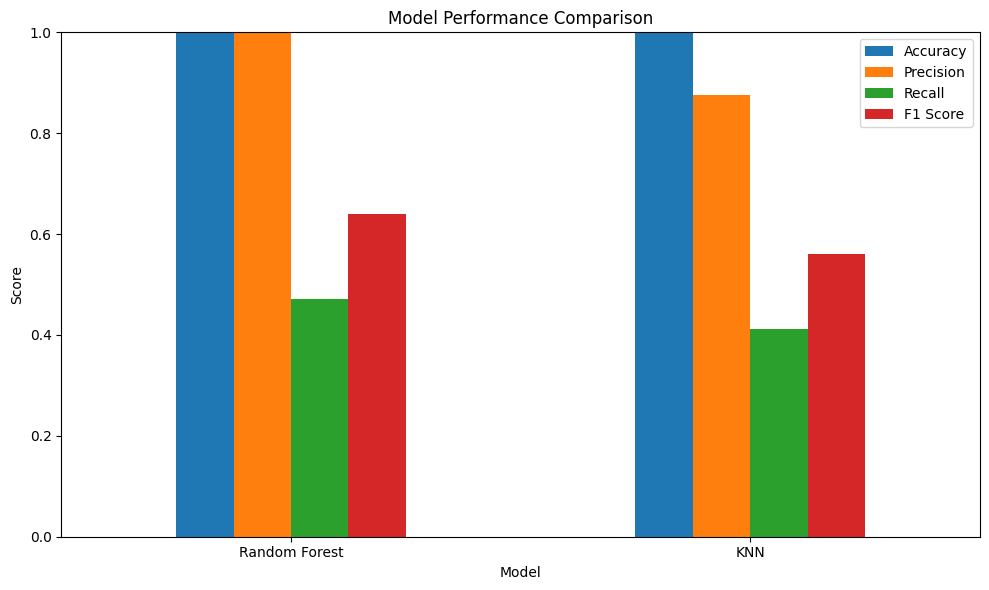

In [ ]:
# ============================================================
# 12. Model Performance Comparison
# ============================================================

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

# KNN metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, zero_division=0)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "KNN"],
    "Accuracy": [rf_accuracy, knn_accuracy],
    "Precision": [rf_precision, knn_precision],
    "Recall": [rf_recall, knn_recall],
    "F1 Score": [rf_f1, knn_f1]
})

print("\n========================================")
print("MODEL PERFORMANCE COMPARISON")
print("========================================")
print(comparison.to_string(index=False))

# Plot model performance comparison
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("model_performance_comparison.png", dpi=150)
plt.show()
plt.close()


## 13. Detailed Random Forest evaluation


In [ ]:
# ============================================================
# 13. Detailed Random Forest evaluation
# ============================================================
print("\n========================================")
print("RANDOM FOREST DETAILED REPORT")
print("========================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))



RANDOM FOREST DETAILED REPORT

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5983
           1       1.00      0.47      0.64        17

    accuracy                           1.00      6000
   macro avg       1.00      0.74      0.82      6000
weighted avg       1.00      1.00      1.00      6000


Confusion Matrix:
[[5983    0]
 [   9    8]]


## 14. Accuracy, Precision, Recall and F1 Score


In [ ]:
# ============================================================
# 14. Accuracy, Precision, Recall and F1 Score
# ============================================================
print("\n========================================")
print("MODEL EVALUATION")
print("========================================")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_rf, zero_division=0))



MODEL EVALUATION
Accuracy : 0.9985
Precision: 1.0
Recall   : 0.47058823529411764
F1 Score : 0.64


## 15. Feature importance



Top 20 Important Features:
                       Feature  Importance
7        origin_balance_change    0.209767
0                         step    0.135474
3               newbalanceOrig    0.118025
14                type_PAYMENT    0.108733
10        origin_balance_empty    0.094118
2                oldbalanceOrg    0.087990
4               oldbalanceDest    0.065564
1                       amount    0.063829
8   destination_balance_change    0.030717
15               type_TRANSFER    0.030408
5               newbalanceDest    0.028061
11   destination_balance_empty    0.012429
12               type_CASH_OUT    0.008573
9            large_transaction    0.005029
13                  type_DEBIT    0.001282
6               isFlaggedFraud    0.000000


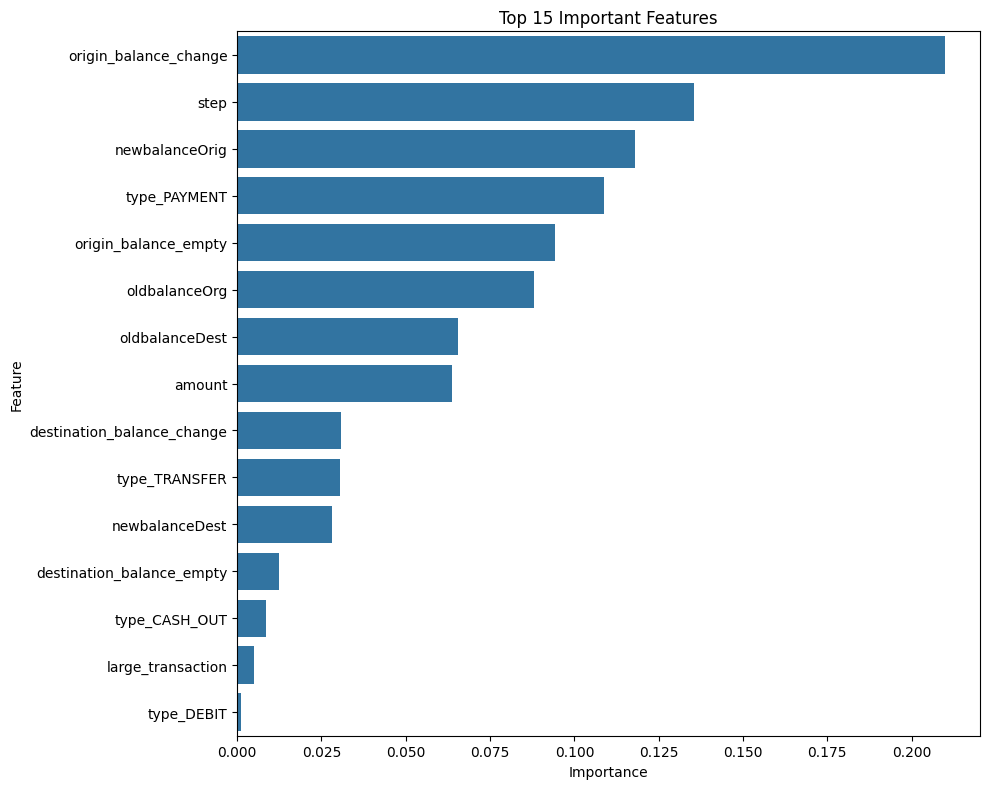

In [ ]:
# ============================================================
# 15. Feature importance
# ============================================================
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features:")
print(feature_importance.head(20))


plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.tight_layout()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
plt.close()


## 16. Save the trained model


In [ ]:
# ============================================================
# 16. Save the trained model
# ============================================================
joblib.dump(X.columns.tolist(), "features_1.pkl")
joblib.dump(classifier_rf.best_estimator_, "model_1.pkl")
joblib.dump(scaler, "scaler_1.pkl")

print("\n========================================")
print("MODEL SAVED SUCCESSFULLY")
print("========================================")
print("features_1.pkl")
print("model_1.pkl")
print("scaler_1.pkl")

print("\n========================================")
print("ALL TASKS COMPLETED SUCCESSFULLY")
print("========================================")
print("Plots saved:")
print(" - fraud_vs_nonfraud.png")
print(" - transaction_amount_distribution.png")
print(" - feature_importance.png")
print(" - model_performance_comparison.png")
print("Models saved:")
print(" - features_1.pkl")
print(" - model_1.pkl")
print(" - scaler_1.pkl")



MODEL SAVED SUCCESSFULLY
features_1.pkl
model_1.pkl
scaler_1.pkl

ALL TASKS COMPLETED SUCCESSFULLY
Plots saved:
 - fraud_vs_nonfraud.png
 - transaction_amount_distribution.png
 - feature_importance.png
 - model_performance_comparison.png
Models saved:
 - features_1.pkl
 - model_1.pkl
 - scaler_1.pkl
